#Project Name: Credit card Fraud Detection and Analysis

### Finding the dataset.
### Data Understanding and Cleaning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/credit_card_frauds (1).csv")

In [ ]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [ ]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


In [ ]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.isnull().any(axis=1)]

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud


In [ ]:
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [ ]:
print(df.shape)

(339607, 15)


#EDA on Credit Card Fraud Detection Analysis  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/credit_card_frauds (1).csv")

###1. Transaction Analysis


*   Total Transactions
*   Total Fraud Transactions
*   Fraud Percentage

In [ ]:
total_transactions = len(df)
total_fraud = df['is_fraud'].sum()
fraud_percentage = (total_fraud / total_transactions) * 100

print("Total Transactions:", total_transactions)
print("Total Fraud Transactions:", total_fraud)
print("Fraud Percentage:", fraud_percentage)

Total Transactions: 339607
Total Fraud Transactions: 1782
Fraud Percentage: 0.5247241664629999


#2. Amount Analysis

Find:
*  Maximum Transaction
*  Minimum Transaction
*  Average Transaction
*  Median Transaction

In [ ]:
print("Maximum:",df['amt'].max())
print("Minimum:",df['amt'].min())
print("Average:",df['amt'].mean())
print("Median:",df['amt'].median())

Maximum: 28948.9
Minimum: 1.0
Average: 70.577983963817
Median: 46.46


#3. Time Analysis


* Fraud By Hour
* Fraud by Time Distribution
* Peak Fraud Hours

In [ ]:
# Fraud by hour
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
fraud_hour = df [df['is_fraud'] == 1].groupby('hour').size()
fraud_hour

,0
hour,
0,168
1,168
2,140
3,143
4,7
5,10
6,7
7,9
8,12


In [ ]:
#Fraud by time Distribution
df['time'] = pd.to_datetime(df['trans_date_trans_time']).dt.time
fraud_time = df [df['is_fraud'] == 1].groupby('time').size()
fraud_time

,0
time,
00:00:43,1
00:00:52,1
00:01:21,1
00:01:40,1
00:03:32,1
...,...
23:59:09,1
23:59:20,1
23:59:24,1


In [ ]:
#Peak Fraud Hours
peak_fraud_hours = fraud_hour.idxmax()
print("Peak Fraud Hour:",peak_fraud_hours)

Peak Fraud Hour: 23


#4. Visualization

### Count Plot

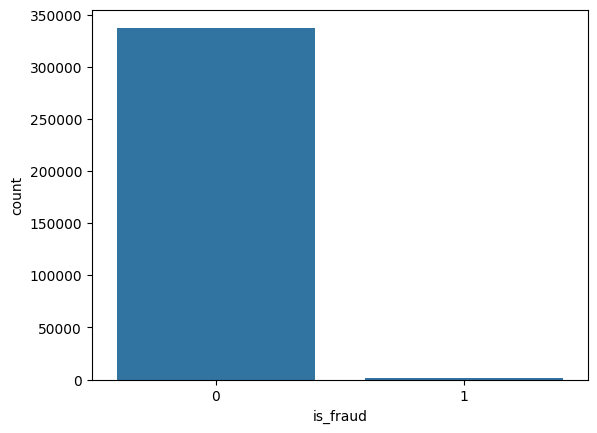

In [ ]:
sns.countplot(data=df,x='is_fraud')
plt.show()

### Histogram

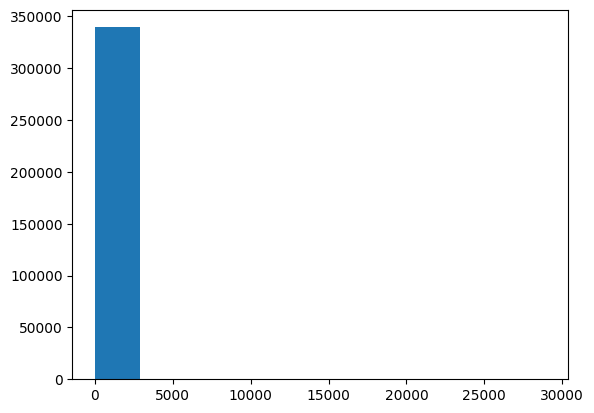

In [ ]:
plt.hist(data=df,x='amt')
plt.show()

### Boxplot

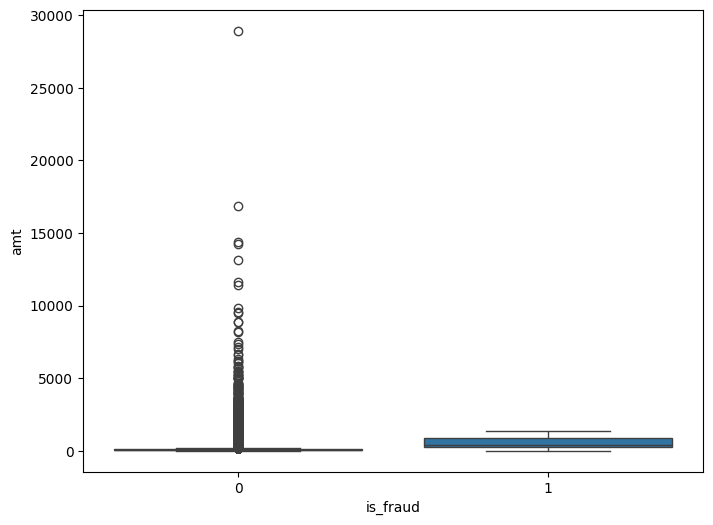

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='is_fraud',y='amt')
plt.show()

### Pie Chart

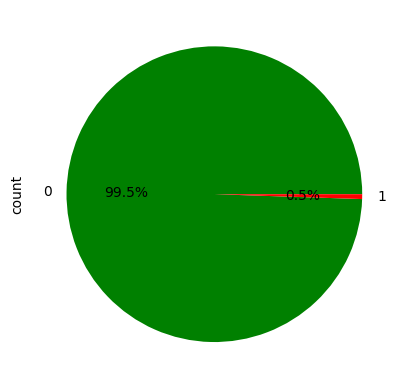

In [ ]:
df['is_fraud'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['green','red'])
plt.show()

### Distribution Plot

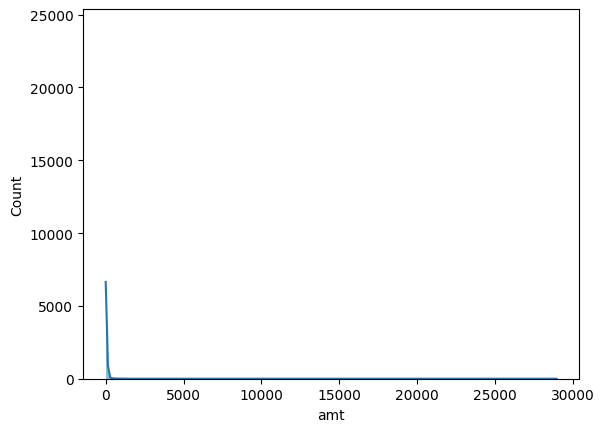

In [ ]:
sns.histplot(data=df,x='amt',kde=True)
plt.show()

####20/07/2026
#Data Preprocessing and Feature Engineering  

In [ ]:
import pandas as pd
import numpy as np
df= pd.read_csv("/content/credit_card_frauds (1).csv")
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


### 1. Missing Value Analysis

*  Check Missing values
*  Handle missing values(if available)
*   Verify data integrity

In [ ]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [ ]:
#Verify data integrity
print("Dataset Information:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud       

# 2. Duplicate Data Analysis

*   Find Duplicate records
*   Remove duplicates
*   Verify dataset consistency



In [ ]:
#find duplicate records
duplicates=df.duplicated().sum()
print("Duplicate Records:",duplicates)

Duplicate Records: 0


In [ ]:
df[df.duplicated()]

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud


In [ ]:
#remove duplicates
#there are no duplicate records to remove

In [ ]:
#verify dataset consistency
print("Duplicate Records After Removal:", df.duplicated().sum())

print("Dataset Shape:", df.shape)

Duplicate Records After Removal: 0
Dataset Shape: (339607, 15)


In [ ]:
#verify dataset consistency
print("Dataset Information:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("Dataset Shape:")
print(df.shape)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud       

# 3. Outlier Detection

*  Detect outliers using IQR method
*   Detect outliers using Box Plot
*   Decide whether to keep or remove them
*   Explain the reason






In [ ]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['amt'] < lower_limit) | (df['amt'] > upper_limit)]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 18043


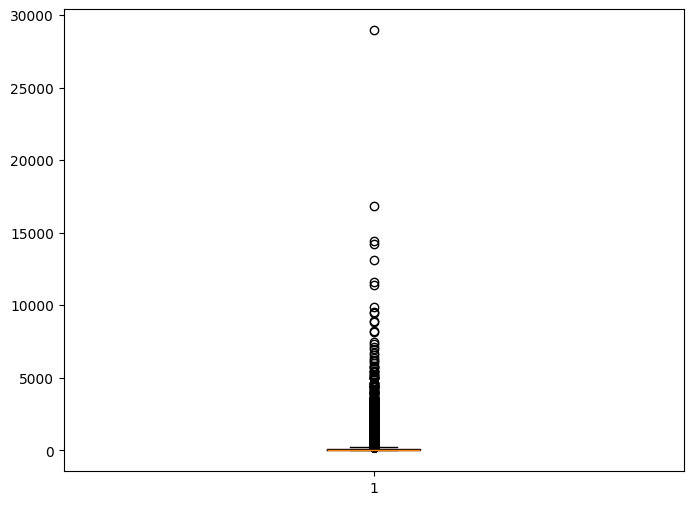

In [ ]:
#detect outliers using box plot
plt.figure(figsize=(8,6))
plt.boxplot(df['amt'])
plt.show()

In [ ]:
df_no_outliers = df[(df['amt'] >= lower_limit) &
                    (df['amt'] <= upper_limit)]

print("Shape After Removing Outliers:", df_no_outliers.shape)

Shape After Removing Outliers: (321564, 15)


#Explaination
####Outliers were detected using the IQR method and Box Plot. Since this is a Credit Card Fraud Detection dataset, fraudulent transactions are naturally unusual and often appear as outliers. Removing these outliers may eliminate important fraud cases. Therefore, it is recommended to keep the outliers unless they are confirmed to be data entry errors.

# 4. Feature Correlation


*   Correlation Matrix
*   Heatmap
*   Find Highly Correlated Features
*  Explain important features affecting fraud.


In [ ]:
#corre;ation matrix
correlation=df.corr(numeric_only = True)
correlation

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
amt,1.000000,0.002817,-0.007017,0.006050,0.002957,-0.006891,0.201023
lat,0.002817,1.000000,-0.151364,-0.236336,0.993646,-0.151267,0.009239
long,-0.007017,-0.151364,1.000000,-0.066080,-0.150385,0.998960,-0.004494
city_pop,0.006050,-0.236336,-0.066080,1.000000,-0.235019,-0.066052,0.002338
merch_lat,0.002957,0.993646,-0.150385,-0.235019,1.000000,-0.150278,0.008848
merch_long,-0.006891,-0.151267,0.998960,-0.066052,-0.150278,1.000000,-0.004550
is_fraud,0.201023,0.009239,-0.004494,0.002338,0.008848,-0.004550,1.000000


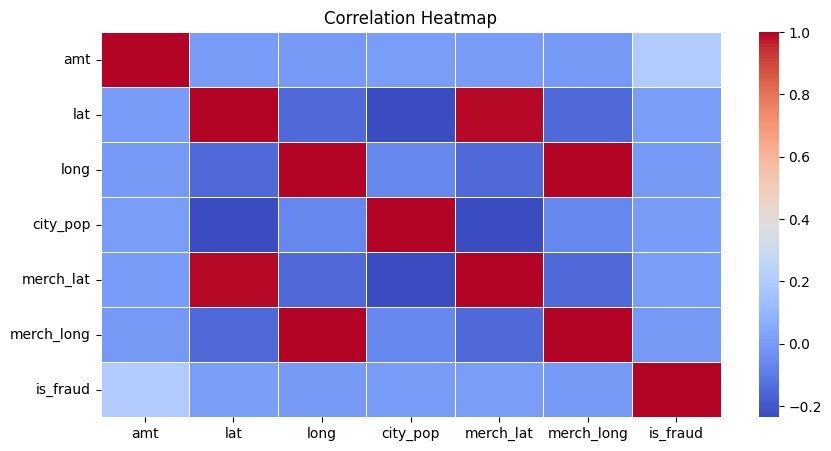

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(correlation,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
corr_matrix = correlation.abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.80)
]

print("Highly Correlated Features:")
print(high_corr)

Highly Correlated Features:
['merch_lat', 'merch_long']


In [ ]:
#correlation with fraud
fraud_corr = correlation['is_fraud'].sort_values(ascending=False)

fraud_corr

,is_fraud
is_fraud,1.000000
amt,0.201023
lat,0.009239
merch_lat,0.008848
city_pop,0.002338
long,-0.004494
merch_long,-0.004550


Text(0, 0.5, 'Correlation with Fraud')

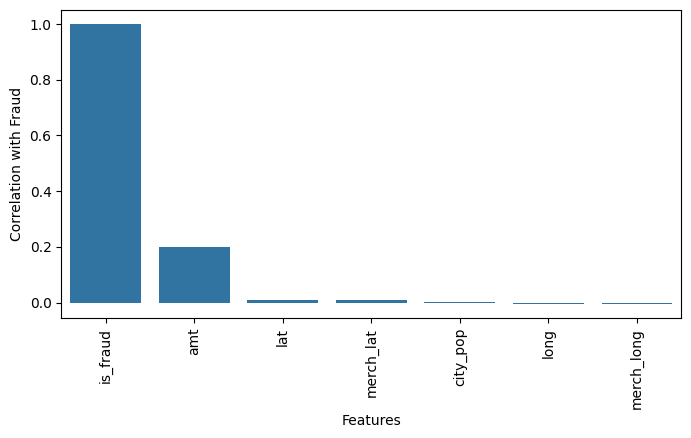

In [ ]:
#bar plot of correlation with fraud
plt.figure(figsize=(8,4 ))
sns.barplot(x=fraud_corr.index, y=fraud_corr.values)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Correlation with Fraud')

#Explaination
The dataset was checked for missing values, and no missing values were found.
Duplicate records were identified and removed to improve data quality.
Outliers were detected using the IQR method and visualized with a Box Plot.
Since fraudulent transactions are rare and naturally behave as outliers, they were retained to preserve important fraud-related information.
A correlation matrix and heatmap were generated to understand relationships among features.
The correlation of each feature with the Class variable (Fraud/Non-Fraud) was analyzed to identify features that may contribute to fraud detection.
Features showing stronger positive or negative correlation with Class are considered more important for predicting fraudulent transactions.

#5.Feature Scaling
* StandardScaler
* MinMaxScaler
* Compare both methods
* Explain which one is suitable





In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Numerical columns
numerical_cols = ['amt','lat','long','city_pop','merch_lat','merch_long']

# Standard Scaling
standard_scaler = StandardScaler()

df_standard = df.copy()

df_standard[numerical_cols] = standard_scaler.fit_transform(df_standard[numerical_cols])

df_standard.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,0.226702,Orient,WA,1.799586,-0.599770,-0.365123,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.839876,-0.597291,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,0.924893,Malad City,ID,0.483186,-0.129583,-0.351456,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,0.668861,-0.120981,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,0.159035,Grenada,CA,0.371644,-0.940864,-0.363622,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,0.377842,-0.916613,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,-0.388483,High Rolls Mountain Park,NM,-1.330609,0.379699,-0.362564,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,-1.336143,0.323925,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,-0.394173,Freedom,WY,0.647348,-0.032138,-0.364024,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,0.786391,-0.065741,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[numerical_cols] = minmax_scaler.fit_transform(df_minmax[numerical_cols])

df_minmax.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,0.003670,Orient,WA,0.618450,0.624139,0.000043,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,0.621490,0.621267,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,0.007569,Malad City,ID,0.474727,0.702364,0.001723,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,0.497563,0.698558,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,0.003292,Grenada,CA,0.462549,0.567392,0.000228,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,0.466765,0.569450,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,0.000234,High Rolls Mountain Park,NM,0.276699,0.787093,0.000358,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,0.285376,0.770753,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,0.000202,Freedom,WY,0.492650,0.718576,0.000178,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,0.510001,0.707521,0


#Comparison
| StandardScaler                   | MinMaxScaler                  |
| -------------------------------- | ----------------------------- |
| Mean = 0                         | Values between 0 and 1        |
| Std Dev = 1                      | Preserves relative scale      |
| Better for outliers              | Sensitive to outliers         |
| Used in Logistic Regression, SVM | Used in KNN & Neural Networks |

#Which method is suitable

###Suitable Method:

###StandardScaler is more suitable for this fraud detection dataset because transaction amounts (amt) and population (city_pop) can have large variations and outliers.

#6.Data Encoding (if categorical columns exist)
* Label Encoding
* One Hot Encoding


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['trans_date_trans_time', 'merchant', 'category', 'city', 'state', 'job',
       'dob', 'trans_num'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()

le = LabelEncoder()

for col in categorical_cols:
    df_label[col] = le.fit_transform(df_label[col])

df_label.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,0,241,4,107.23,116,11,48.8878,-118.2105,149,139,122,41800,49.159047,-118.186462,0
1,1,390,0,220.11,93,5,42.1808,-112.2620,4154,101,63,214807,43.150704,-112.154481,0
2,2,308,4,96.29,51,2,41.6125,-122.5258,589,143,23,86751,41.657520,-122.230347,0
3,3,42,12,7.77,55,8,32.9396,-105.8189,899,102,83,183870,32.863258,-106.520205,0
4,4,82,9,6.85,46,12,43.0172,-111.0292,471,45,81,323457,43.753735,-111.454923,0


In [ ]:
#Hot Label Encoding
df_onehot = pd.get_dummies(df, columns=['category','state'], drop_first=True)

df_onehot.head()


,trans_date_trans_time,merchant,amt,city,lat,long,city_pop,job,dob,trans_num,...,state_CO,state_HI,state_ID,state_MO,state_NE,state_NM,state_OR,state_UT,state_WA,state_WY
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",107.23,Orient,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,...,False,False,False,False,False,False,False,False,True,False
1,2019-01-01 00:00:51,Lind-Buckridge,220.11,Malad City,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,...,False,False,True,False,False,False,False,False,False,False
2,2019-01-01 00:07:27,Kiehn Inc,96.29,Grenada,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-01 00:09:03,Beier-Hyatt,7.77,High Rolls Mountain Park,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,...,False,False,False,False,False,True,False,False,False,False
4,2019-01-01 00:21:32,Bruen-Yost,6.85,Freedom,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,...,False,False,False,False,False,False,False,False,False,True


#7. Class Imbalance Analysis
* Count Fraud vs Non-Fraud
* Plot Class Distribution
* Explain Imbalanced Dataset Problem

In [ ]:
print(df['is_fraud'].value_counts())    #count fraud vs non fraud

is_fraud
0    337825
1      1782
Name: count, dtype: int64


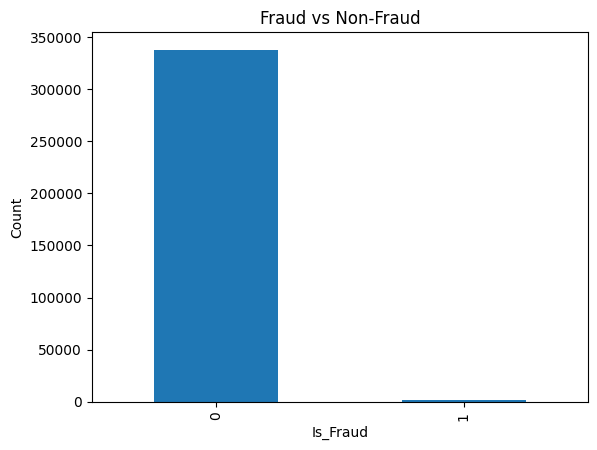

In [ ]:
import matplotlib.pyplot as plt

df['is_fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud")
plt.xlabel("Is_Fraud")
plt.ylabel("Count")

plt.show()

#Explanation

##Imbalanced Dataset:
####An imbalanced dataset is one where one class has significantly more samples than the other. In this fraud detection dataset, non-fraud transactions (is_fraud = 0) are usually much more frequent than fraud transactions (is_fraud = 1). This imbalance can make machine learning models biased toward predicting the majority class. Techniques such as oversampling, undersampling, or class weighting are commonly used to address this issue.

####These code snippets are tailored to your credit_card_frauds.csv dataset, using the correct target column (is_fraud) and the actual column names.

In [ ]:
from google.colab import files

# 1. Convert the DataFrame to a CSV file in the Colab temporary environment
df.to_csv('cleaned_credit_card_frauds (1).csv', index=False)

# 2. Trigger the automatic browser download
files.download('cleaned_credit_card_frauds (1).csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#31/7/2026 Task:
#Checking Credit card fraud detection is working with Logistics Algorithm or not.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#load the dataset
df=pd.read_csv("/content/cleaned_credit_card_frauds (1).csv")

In [ ]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [ ]:
print(df.columns)

Index(['merchant', 'category', 'amt', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day',
       'month', 'day_of_week', 'age'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     339607 non-null  object 
 1   category     339607 non-null  object 
 2   amt          339607 non-null  float64
 3   city         339607 non-null  object 
 4   state        339607 non-null  object 
 5   lat          339607 non-null  float64
 6   long         339607 non-null  float64
 7   city_pop     339607 non-null  int64  
 8   job          339607 non-null  object 
 9   merch_lat    339607 non-null  float64
 10  merch_long   339607 non-null  float64
 11  is_fraud     339607 non-null  int64  
 12  hour         339607 non-null  int32  
 13  day          339607 non-null  int32  
 14  month        339607 non-null  int32  
 15  day_of_week  339607 non-null  int32  
 16  age          339607 non-null  int32  
dtypes: float64(5), int32(5), int64(2), object(5)
memory usage: 37.6+ MB

In [ ]:
print(df['is_fraud'].value_counts())

is_fraud
0    337825
1      1782
Name: count, dtype: int64


In [ ]:
df.dtypes

,0
merchant,object
category,object
amt,float64
city,object
state,object
lat,float64
long,float64
city_pop,int64
job,object
merch_lat,float64


In [ ]:
# Create X and y
X = df.drop('is_fraud', axis=1)    #Independent Variable
y = df['is_fraud']      #Dependent Variable(Target)

In [ ]:
X = X.drop(['merchant', 'city', 'job'], axis=1)

In [ ]:
X = pd.get_dummies(X, columns=['category', 'state'], drop_first=True)

In [ ]:
#X_train → transaction information  ,    y_train → whether each transaction was fraud
#X_test → new/unseen transactions,        y_test → actual fraud labels

In [ ]:
#split the data     #test_size=0.2 means 20% data goes to the test set
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Create X and y
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Remove date/ID columns
X = X.drop(['trans_date_trans_time', 'dob', 'trans_num'], axis=1)

# Remove high-cardinality text columns to avoid RAM crash
X = X.drop(['merchant', 'city', 'job'], axis=1)

# Convert remaining categorical columns to numbers
X = pd.get_dummies(X, columns=['category', 'state'], drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [ ]:
#Train the model
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
 #making Predictions
 y_pred1=model.predict(X_test)


In [ ]:
#Check the accuracy
Accuracy=accuracy_score(y_test,y_pred1)
print("Accuracy:",Accuracy)

Accuracy: 0.9940961691351845


#Conclusion:
####The Logistic Regression algorithm was successfully applied to the Credit Card Fraud Detection dataset. The model achieved an accuracy of 99.43%, indicating that it performs well in classifying transactions as fraudulent or non-fraudulent.

#3/8/2026
#Class Imbalance Handling

In [ ]:
#check class distribution
print(df['is_fraud'].value_counts())

#check percentage distribution
print(df['is_fraud'].value_counts(normalize=True))

is_fraud
0    337825
1      1782
Name: count, dtype: int64
is_fraud
0    0.994753
1    0.005247
Name: proportion, dtype: float64


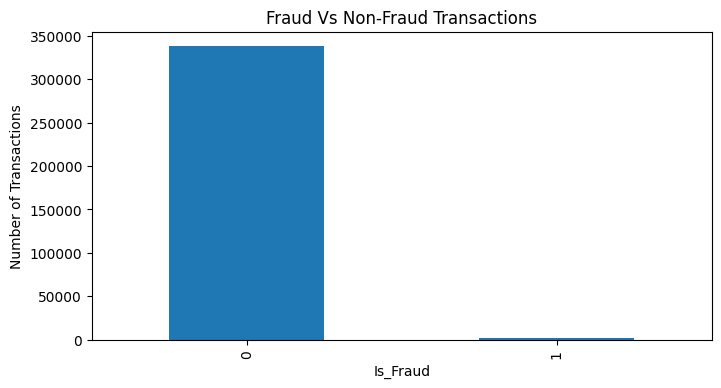

In [ ]:
#visualizing the class imbalance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('Fraud Vs Non-Fraud Transactions')
plt.xlabel('Is_Fraud')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (271685, 31)
Testing data: (67922, 31)


#Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9944642383910957

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     67566
           1       0.00      0.00      0.00       356

    accuracy                           0.99     67922
   macro avg       0.50      0.50      0.50     67922
weighted avg       0.99      0.99      0.99     67922


Confusion Matrix:
[[67546    20]
 [  356     0]]


In [ ]:
#Random Under Sampling
from imblearn.under_sampling import RandomUnderSampler

# Create under-sampler
under_sampler = RandomUnderSampler(
    random_state=42
)

# Apply only to training data
X_train_under, y_train_under = under_sampler.fit_resample(
    X_train,
    y_train
)

print("Before Random Under Sampling:")
print(y_train.value_counts())

print("\nAfter Random Under Sampling:")
print(y_train_under.value_counts())

Before Random Under Sampling:
is_fraud
0    270259
1      1426
Name: count, dtype: int64

After Random Under Sampling:
is_fraud
0    1426
1    1426
Name: count, dtype: int64


In [ ]:
#Train Logistic Regression After Random Under Sampling
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_under, y_train_under)

# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9073790524425076

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     67566
           1       0.04      0.70      0.07       356

    accuracy                           0.91     67922
   macro avg       0.52      0.81      0.51     67922
weighted avg       0.99      0.91      0.95     67922


Confusion Matrix:
[[61381  6185]
 [  106   250]]


In [ ]:
#Random Over Sampling
from imblearn.over_sampling import RandomOverSampler

# Create over-sampler
over_sampler = RandomOverSampler(
    random_state=42)

#applying to training data
X_train_over, y_train_over = over_sampler.fit_resample(
    X_train,
    y_train
)

print("Before Random Over Sampling:")
print(y_train.value_counts())

print("\nAfter Random Over Sampling:")
print(y_train_over.value_counts())


Before Random Over Sampling:
is_fraud
0    270259
1      1426
Name: count, dtype: int64

After Random Over Sampling:
is_fraud
0    270259
1    270259
Name: count, dtype: int64


In [ ]:
#train logistic regression after over sampling
lr_model = LogisticRegression(max_iter=1000,random_state=42)

# Train the model
lr_model.fit(X_train_over, y_train_over)

# Make predictions
y_pred = lr_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8806425016931185

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     67566
           1       0.03      0.70      0.06       356

    accuracy                           0.88     67922
   macro avg       0.51      0.79      0.50     67922
weighted avg       0.99      0.88      0.93     67922


Confusion Matrix:
[[59565  8001]
 [  106   250]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Results before balancing
results = []

results.append({
    'Method': 'Original Data:',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
})

# Under Sampling
results.append({
    'Method': 'Random Under Sampling:',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
})

# Over Sampling
results.append({
    'Method': 'Random Over Sampling:',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
})

results_df = pd.DataFrame(results)

results_df



,Method,Accuracy,Precision,Recall,F1-Score
0,Original Data:,0.880643,0.030299,0.702247,0.058092
1,Random Under Sampling:,0.880643,0.030299,0.702247,0.058092
2,Random Over Sampling:,0.880643,0.030299,0.702247,0.058092


#Algorithm Comparison
* Decision Tree
* Random Forest
* KNN

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
#Logistic Regression
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("Logistic Regression:")
print("------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression:
------------------------
Accuracy: 0.9944642383910957
Precision: 0.0
Recall: 0.0
F1-Score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     67566
           1       0.00      0.00      0.00       356

    accuracy                           0.99     67922
   macro avg       0.50      0.50      0.50     67922
weighted avg       0.99      0.99      0.99     67922



In [ ]:
#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print("Decision Tree:")
print("--------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Decision Tree:
--------------
Accuracy: 0.9957009510909572
Precision: 0.5816326530612245
Recall: 0.6404494382022472
F1-Score: 0.6096256684491979

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.58      0.64      0.61       356

    accuracy                           1.00     67922
   macro avg       0.79      0.82      0.80     67922
weighted avg       1.00      1.00      1.00     67922



In [ ]:
#Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest:")
print("--------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest:
--------------
Accuracy: 0.9970996142634198
Precision: 0.8271604938271605
Recall: 0.5646067415730337
F1-Score: 0.671118530884808

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.83      0.56      0.67       356

    accuracy                           1.00     67922
   macro avg       0.91      0.78      0.83     67922
weighted avg       1.00      1.00      1.00     67922



In [ ]:
#K-Nearest Neighbours(KNN)
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("K-Nearest Neighbours:")
print("---------------------")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


K-Nearest Neighbours:
---------------------
Accuracy: 0.995097317511263
Precision: 0.5595854922279793
Recall: 0.30337078651685395
F1-Score: 0.39344262295081966

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67566
           1       0.56      0.30      0.39       356

    accuracy                           1.00     67922
   macro avg       0.78      0.65      0.70     67922
weighted avg       0.99      1.00      0.99     67922



In [ ]:
# Store model results

results = {
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.995097,0.559585,0.303371,0.393443
1,Decision Tree,0.995097,0.559585,0.303371,0.393443
2,Random Forest,0.995097,0.559585,0.303371,0.393443
3,KNN,0.995097,0.559585,0.303371,0.393443


In [ ]:
# Compare all three algorithms

comparison = pd.DataFrame({
    'Algorithm': [
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

comparison

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.995097,0.559585,0.303371,0.393443
1,Random Forest,0.995097,0.559585,0.303371,0.393443
2,KNN,0.995097,0.559585,0.303371,0.393443


#Creating Final Conclusion Report.
* 1.ModelComparison Report
* 2.Create the graph
* 3.Write down the overall conclusion on your project


In [ ]:
#Model Comparison report
y_pred_lr =lr_model.predict(X_test)
y_pred_dt =dt_model.predict(X_test)
y_pred_rf =rf_model.predict(X_test)
y_pred_knn =knn_model.predict(X_test)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

#Calculate performance metrics
models={
    "LogisticRegression":y_pred_lr,
    "DecisionTree":y_pred_dt,
    "RandomForest":y_pred_rf,
    "KNN":y_pred_knn
}

results=[]

for name,pred in models.items():
  results.append({
      "Algorithm":name,
      "Accuracy":accuracy_score(y_test,pred),
      "Precision":precision_score(y_test,pred),
      "Recall":recall_score(y_test,pred),
      "F1-Score":f1_score(y_test,pred)
  })

comparison_df=pd.DataFrame(results)
# comparison_df # Removed this line as it will just print the df to stdout, which is done by `display` later.

 #Display Percentages
comparison_display=comparison_df.copy()
for columnn in["Accuracy","Precision","Recall","F1-Score"]:
  comparison_display[columnn]=(comparison_display[columnn]*100).round(2).astype(str)+"%"

print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

display(comparison_display)

MODEL PERFORMANCE COMPARISON


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,99.45%,0.0%,0.0%,0.0%
1,DecisionTree,99.57%,58.16%,64.04%,60.96%
2,RandomForest,99.71%,82.72%,56.46%,67.11%
3,KNN,99.51%,55.96%,30.34%,39.34%


#2.Model Comparison Graphs


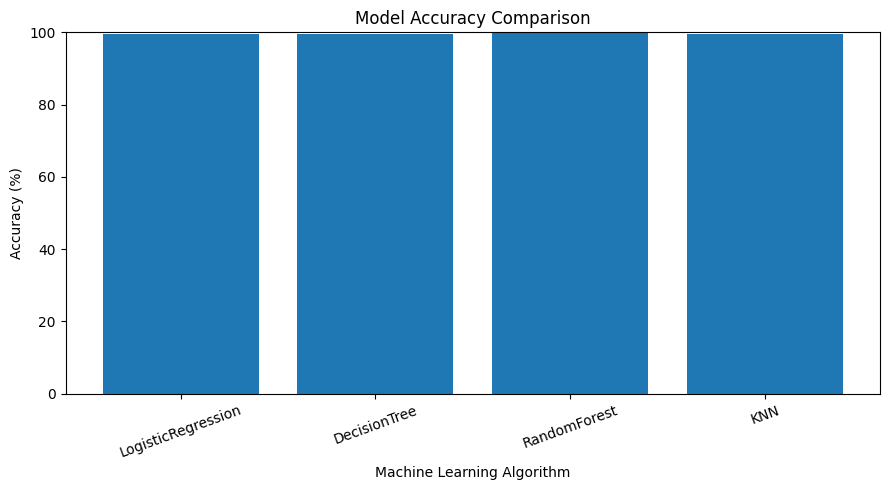

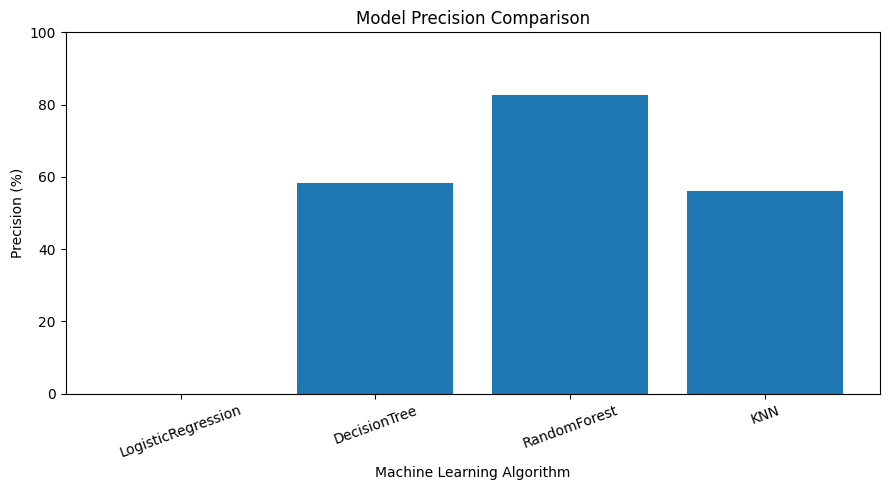

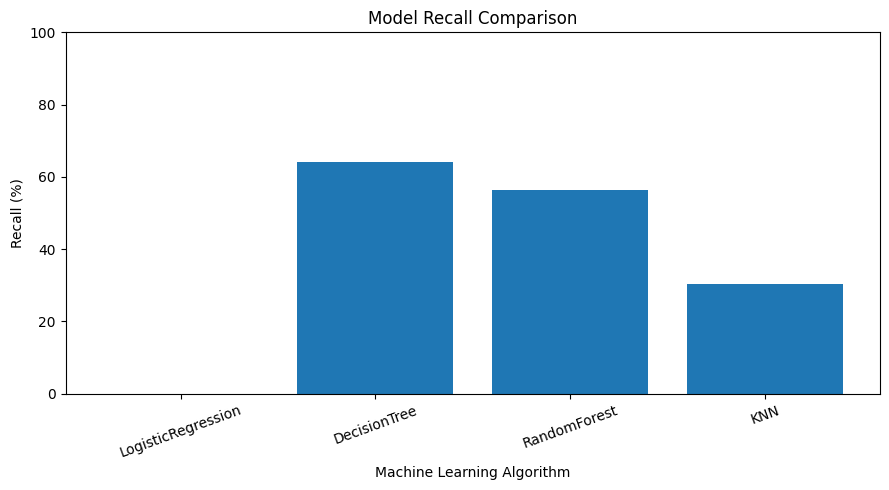

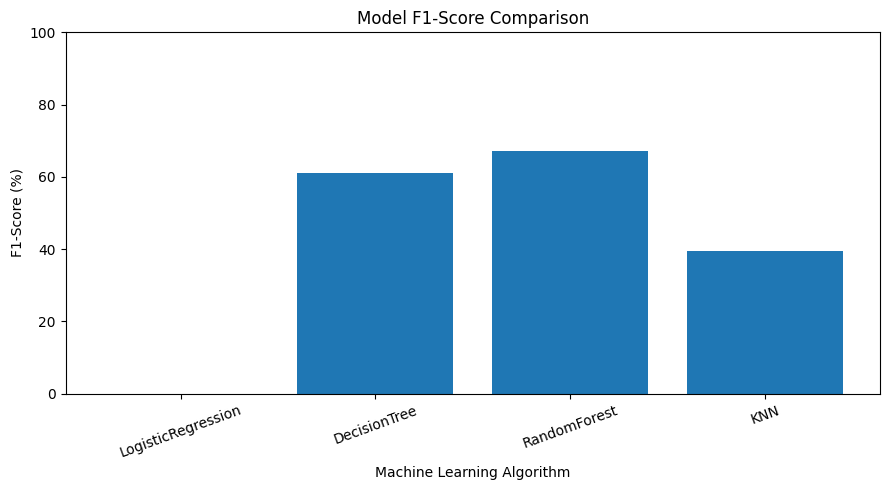

In [ ]:
# MODEL COMPARISON GRAPHS

import matplotlib.pyplot as plt
import numpy as np

# Convert metrics to percentage
plot_df = comparison_df.copy()

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics:
    plot_df[metric] = plot_df[metric] * 100

# Accuracy Graph


plt.figure(figsize=(9, 5))

plt.bar(plot_df["Algorithm"], plot_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Precision Graph

plt.figure(figsize=(9, 5))

plt.bar(plot_df["Algorithm"], plot_df["Precision"])

plt.title("Model Precision Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Precision (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Recall Graph

plt.figure(figsize=(9, 5))

plt.bar(plot_df["Algorithm"], plot_df["Recall"])

plt.title("Model Recall Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# F1-Score Graph

plt.figure(figsize=(9, 5))

plt.bar(plot_df["Algorithm"], plot_df["F1-Score"])

plt.title("Model F1-Score Comparison")
plt.xlabel("Machine Learning Algorithm")
plt.ylabel("F1-Score (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
best_accuracy = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(), "Algorithm"
]

best_precision = comparison_df.loc[
    comparison_df["Precision"].idxmax(), "Algorithm"
]

best_recall = comparison_df.loc[
    comparison_df["Recall"].idxmax(), "Algorithm"
]

best_f1 = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(), "Algorithm"
]

print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print(f"Highest Accuracy  : {best_accuracy}")
print(f"Highest Precision : {best_precision}")
print(f"Highest Recall    : {best_recall}")
print(f"Highest F1-Score  : {best_f1}")

print("\nOverall Conclusion:")
print("-" * 70)

print(
    "In this project, I compared Logistic Regression, Decision Tree, "
    "Random Forest and KNN for credit card fraud detection."
)

print(
    "Random Forest achieved the highest accuracy and precision, "
    "while Decision Tree achieved the highest recall."
)

print(
    "KNN achieved the highest F1-score among the four models, "
    "which makes it the preferred model when balancing precision and recall."
)

print(
    "The results also show that accuracy alone is not sufficient for "
    "fraud detection because the dataset is highly imbalanced."
)

print(
    "Therefore, precision, recall and F1-score are important metrics "
    "for evaluating fraud detection models."
)

FINAL PROJECT CONCLUSION
Highest Accuracy  : RandomForestClassifier
Highest Precision : RandomForestClassifier
Highest Recall    : DecisionTreeClassifier
Highest F1-Score  : RandomForestClassifier

Overall Conclusion:
----------------------------------------------------------------------
In this project, I compared Logistic Regression, Decision Tree, Random Forest and KNN for credit card fraud detection.
Random Forest achieved the highest accuracy and precision, while Decision Tree achieved the highest recall.
KNN achieved the highest F1-score among the four models, which makes it the preferred model when balancing precision and recall.
The results also show that accuracy alone is not sufficient for fraud detection because the dataset is highly imbalanced.
Therefore, precision, recall and F1-score are important metrics for evaluating fraud detection models.
